# P4: Modelo de Mezcla Gaussiana

**Contenido del notebook.**
1. Verificación numérica de los ejercicios 1 y 2.
2. Clasificación generativa de vocales en el plano $(F_1,F_2)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix, accuracy_score

plt.rcParams['figure.figsize'] = (10, 4)
np.set_printoptions(precision=3, suppress=True)

In [3]:
GaussianMixture.predict_proba?

Signature: GaussianMixture.predict_proba(self, X)
Docstring:
Evaluate the components' density for each sample.

Parameters
----------
X : array-like of shape (n_samples, n_features)
    List of n_features-dimensional data points. Each row
    corresponds to a single data point.

Returns
-------
resp : array, shape (n_samples, n_components)
    Density of each Gaussian component for each sample in X.
File:      c:\users\dante p\miniconda3\envs\habla\lib\site-packages\sklearn\mixture\_base.py
Type:      function

## Ejercicio 3. Verificación numérica de los ejercicios 1 y 2

In [2]:
# Ejercicio 1: log-verosimilitud gaussiana en el plano (F1, F2)
y_obs = np.array([500, 1500])
mu = np.array([300, 2200])
Sigma = np.array([[1600, 0], [0, 10000]])

delta = y_obs - mu ### <-- COMPLETAR
mahala_sq = delta @ np.linalg.inv(Sigma) @ delta ### <-- COMPLETAR
det_Sigma = np.linalg.det(Sigma) ### <-- COMPLETAR
logp_manual = -0.5 * ( np.log(det_Sigma) + mahala_sq + 2 * np.log(2 * np.pi)   ) ### <-- COMPLETAR
logp_scipy = multivariate_normal(mean=mu, cov=Sigma).logpdf(y_obs)

print('d^2 Mahalanobis =', mahala_sq)
print('log p(y), manual =', logp_manual)
print('log p(y), scipy  =', logp_scipy)

d^2 Mahalanobis = 74.0
log p(y), manual = -47.13192670651138
log p(y), scipy  = -47.13192670651137


In [3]:
# Ejercicio 2: un paso de EM con varianzas fijas en 1.
y = np.array([1.0, 2.0, 5.0])
omega = np.array([0.5, 0.5])
mu = np.array([1.5, 4.5])
var = np.array([1.0, 1.0])

def log_likelihood(y, omega, mu, var):
    dens = np.zeros((len(y), len(omega)))
    for m in range(len(omega)):
        dens[:, m] = omega[m] * norm.pdf(y, loc=mu[m], scale=np.sqrt(var[m]))
    return np.sum(np.log(np.sum(dens, axis=1)))

l0 = log_likelihood(y, omega, mu, var)

# Paso E
num = np.zeros((len(y), 2))
for m in range(2):
    num[:, m] = omega[m] * norm.pdf(y, loc = mu[m], scale=np.sqrt(var[m])) ### <-- COMPLETAR numerador de gamma

gamma = num / np.sum(num, axis=1, keepdims = True) ### <-- COMPLETAR normalizando por fila

# Paso M: actualizamos pesos y medias; dejamos varianzas fijas.
N_m = gamma.sum(axis=0)  ### <-- COMPLETAR 
omega_nuevo = N_m / len(y)### <-- COMPLETAR 
mu_nuevo =   np.sum( y @ gamma) / N_m ### <-- COMPLETAR 
# Forma de Kevin: mu_nuevo = (gamma * y[:, None]).sum(axis=0) / N_m
var_nueva = var.copy()
l1 = log_likelihood(y, omega_nuevo, mu_nuevo, var_nueva)

print('Responsabilidades gamma:')
print(gamma)
print('omega nuevo =', omega_nuevo)
print('mu nuevo =', mu_nuevo)
print('log-verosimilitud inicial =', l0)
print('log-verosimilitud luego de un paso =', l1)

Responsabilidades gamma:
[[0.998 0.002]
 [0.953 0.047]
 [0.002 0.998]]
omega nuevo = [0.651 0.349]
mu nuevo = [4.097 7.638]
log-verosimilitud inicial = -5.157718419444651
log-verosimilitud luego de un paso = -11.423423397019464


**Interpretación:** <mark>COMPLETAR</mark>.

## Ejercicio 4. Clasificación de vocales por $(F_1,F_2)$

Generamos datos sintéticos de tres vocales. Cada observación es un vector

$$
\mathbf y=
\begin{bmatrix}
F_1\\
F_2
\end{bmatrix}.
$$

Para representar variabilidad dentro de cada vocal, generamos dos subpoblaciones. Partimos de una media de referencia $\boldsymbol\mu_k$ y usamos

$$
\boldsymbol\mu_{k1}=0{,}92\,\boldsymbol\mu_k,
\qquad
\boldsymbol\mu_{k2}=1{,}08\,\boldsymbol\mu_k.
$$

Estas dos medias representan esquemáticamente dos grupos de hablantes con formantes algo más bajos o más altos. Por lo tanto, cada vocal se modelará mediante una GMM de dos componentes:

$$
p(\mathbf y\mid S=s_k)
=
\sum_{m=1}^{2}
\omega_{km}
\mathcal N(
\mathbf y;
\boldsymbol\mu_{km},
\boldsymbol\Sigma_{km}
).
$$

El índice $k$ identifica la vocal y el índice $m$ identifica una componente dentro de esa vocal. Durante el entrenamiento conocemos la vocal de cada observación, pero no indicamos a qué subpoblación pertenece: la GMM debe descubrir esas componentes mediante EM.

In [4]:
rng = np.random.default_rng(2)

vocales = ['a', 'i', 'u']
factores = [0.92, 1.08]
N = 160
X = []
labels = []

medias = {
    # COMPLETAR medias de /a/, /i/, /u/ en el plano (F1, F2)
    'a': np.array([750, 1300]),
    'i': np.array([300, 2300]),
    'u': np.array([350, 800]),
}

# Covarianzas con distintas formas para que las fronteras no sean triviales.
covs = {
    'a': np.array([[70**2, 0.35*70*130], [0.35*70*130, 130**2]]),
    'i': np.array([[45**2, -0.25*45*160], [-0.25*45*160, 160**2]]),
    'u': np.array([[50**2, 0.20*50*110], [0.20*50*110, 110**2]]),
}


for idx, v in enumerate(vocales):
    for factor in factores:
        pts = rng.multivariate_normal(factor*medias[v], 0.55*covs[v], size=N//2)
        X.append(pts)
        labels.append(np.full(N//2, idx))
X = np.vstack(X)
labels = np.concatenate(labels)

perm = rng.permutation(len(X))
X, labels = X[perm], labels[perm]

n_train = int(0.7 * len(X))
X_train, X_test = X[:n_train], X[n_train:]
labels_train, labels_test = labels[:n_train], labels[n_train:]

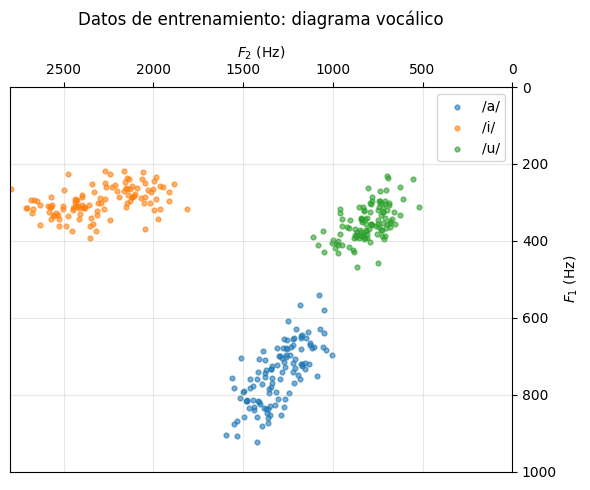

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))

for idx, v in enumerate(vocales):
    pts = X_train[labels_train == idx]
    ax.scatter(pts[:, 1], pts[:, 0], s=12, alpha=0.6, label=f'/{v}/')

ax.set_xlim(2800, 0)
ax.set_ylim(1000, 0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.yaxis.tick_right()
ax.yaxis.set_label_position('right')

ax.set_xlabel(r'$F_2$ (Hz)')
ax.set_ylabel(r'$F_1$ (Hz)')
ax.set_title('Datos de entrenamiento: diagrama vocálico', pad=45)

ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [6]:
# Entrenamos una GMM de dos componentes por vocal
modelos = []
for idx, v in enumerate(vocales):
    gm = GaussianMixture(n_components=2, covariance_type='full', init_params='random_from_data', n_init=10, max_iter=300, random_state=0)
    gm.fit(X_train[labels_train == idx]) # COMPLETAR: entrenar con los puntos de la clase idx
    modelos.append(gm)

# Como generamos la misma cantidad de ejemplos de cada vocal, suponemos priors iguales.
priors = np.full( len(vocales), 1/len(vocales) ) ### <-- COMPLETAR

for v, modelo in zip(vocales, modelos):
    print(f'Vocal /{v}/')
    print('Pesos:', modelo.weights_)
    print('Medias:')
    print(modelo.means_)

def predecir_por_modelos(X_eval, modelos, priors):
    # COMPLETAR: armar matriz de log-verosimilitudes (una columna por clase) y MAP
    log_likelihoods = np.column_stack( [modelo.score_samples(X_eval) for modelo in modelos] )
    scores = log_likelihoods + np.log(priors)[None, :]
    return np.argmax(scores, axis=1), scores

labels_pred, scores = predecir_por_modelos(X_test, modelos, priors)
print('Accuracy:', accuracy_score(labels_test, labels_pred))
print('Matriz de confusión:')
print(confusion_matrix(labels_test, labels_pred))

Vocal /a/
Pesos: [0.475 0.525]
Medias:
[[ 807.148 1410.371]
 [ 692.393 1209.106]]
Vocal /i/
Pesos: [0.469 0.531]
Medias:
[[ 271.396 2107.116]
 [ 319.53  2474.914]]
Vocal /u/
Pesos: [0.521 0.479]
Medias:
[[371.162 857.926]
 [333.559 749.159]]
Accuracy: 1.0
Matriz de confusión:
[[46  0  0]
 [ 0 47  0]
 [ 0  0 51]]


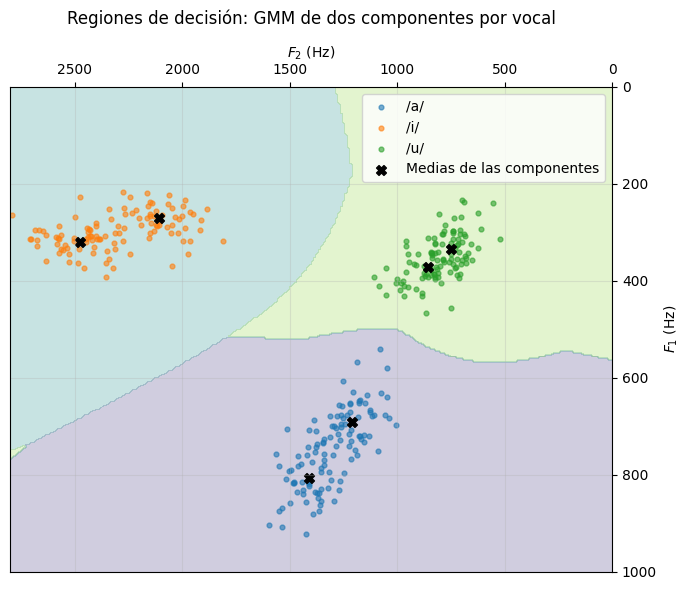

In [7]:
# Visualizamos regiones de decisión en el plano (F1, F2)
F1_grid = np.linspace(0, 1000, 250)
F2_grid = np.linspace(0, 2800, 250)

FF1, FF2 = np.meshgrid(F1_grid, F2_grid)
grid = np.column_stack([FF1.ravel(), FF2.ravel()])

pred_grid, _ = predecir_por_modelos(grid, modelos, priors)
pred_grid = pred_grid.reshape(FF1.shape)

fig, ax = plt.subplots(figsize=(7, 6))

ax.contourf(FF2, FF1, pred_grid, alpha=0.25, levels=np.arange(len(vocales) + 1) - 0.5)

for idx, v in enumerate(vocales):
    pts = X_train[labels_train == idx]
    ax.scatter(pts[:, 1], pts[:, 0], s=12, alpha=0.6, label=f'/{v}/')

for idx, modelo in enumerate(modelos):
    etiqueta = 'Medias de las componentes' if idx == 0 else None
    ax.scatter(modelo.means_[:, 1], modelo.means_[:, 0], marker='X', s=50, c='black', label=etiqueta)

ax.set_xlim(2800, 0)
ax.set_ylim(1000, 0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.yaxis.tick_right()
ax.yaxis.set_label_position('right')

ax.set_xlabel(r'$F_2$ (Hz)')
ax.set_ylabel(r'$F_1$ (Hz)')
ax.set_title('Regiones de decisión: GMM de dos componentes por vocal', pad=45)

ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

**Conclusión:** <mark>COMPLETAR</mark>.